In [1]:
using DifferentialEquations, LinearAlgebra, Plots, LaTeXStrings, PGFPlotsX
gr()

Plots.GRBackend()

In [2]:
# Basis states
r = [0; 1]  # Assume |1>
g = [1; 0]  # Assume |0>

#Initial state
α = 1
β = sqrt(1-α^2)
ψ_a = α.*r + β.*g
ψ_1 = g

ρ_0 = complex(kron(ψ_a,ψ_1) * kron(ψ_a,ψ_1)');
#ρ_0 /=tr(ρ_0)

4×4 Matrix{ComplexF64}:
 0.0+0.0im  0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  1.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im  0.0+0.0im

In [3]:
function master_eqn(dρ,ρ,p,t)

    #2x2 Matrices
    σ_x = [0 1; 1 0]
    n = [0 0; 0 1]
    I = [1 0; 0 1]
    σ_minus = [0 1; 0 0]
    σ_plus = [0 0; 1 0]
    σ_z = [1 0; 0 -1]

    #parameters
    Ω = p[1]
    Δ = p[2]
    γ_D = p[3]
    γ_d = p[4]

    #ρ /= tr(ρ)
    
    #Hamiltonian
    H = Ω/2 .* kron(I,σ_x) + Δ .* kron(I,n) - Δ .* kron(n,n)
    l_decay = γ_D .* (kron(I,σ_minus) * ρ * kron(I,σ_plus) - 0.5.*((kron(I,σ_plus) * kron(I,σ_minus) * ρ) + (ρ * kron(I,σ_plus) * kron(I,σ_minus))))
    l_dephase = γ_d .* (kron(I,σ_z) * ρ * kron(I,σ_z) - ρ)

    dρ .= -1im .* (H*ρ - ρ*H) + l_decay + l_dephase
    print(dρ)

end

master_eqn (generic function with 1 method)

In [4]:
tspan = (0.0,100)   #time span
p = [1,1000,0.0,0.0]  #[Ω,Δ,γ_Decay,γ_dephase]

#solving diff master_eqn
eqn = ODEProblem(master_eqn,ρ_0,tspan,p)
sol = solve(eqn,Tsit5(),saveat = 0.01);

ComplexF64[0.0 + 0.0im 0.0 + 0.0im 0.0 + 0.0im 0.0 + 0.0im; 0.0 + 0.0im 0.0 + 0.0im 0.0 + 0.0im 0.0 + 0.0im; 0.0 + 0.0im 0.0 + 0.0im 0.0 + 0.0im 0.0 + 0.5im; 0.0 + 0.0im 0.0 + 0.0im 0.0 - 0.5im 0.0 + 0.0im]ComplexF64[0.0 + 0.0im 0.0 + 0.0im 0.0 + 0.0im 0.0 + 0.0im; 0.0 + 0.0im 0.0 + 0.0im 0.0 + 0.0im 0.0 + 0.0im; 0.0 + 0.0im 0.0 + 0.0im 0.0 + 0.0im 0.0 + 0.5im; 0.0 + 0.0im 0.0 + 0.0im 0.0 - 0.5im 0.0 + 0.0im]ComplexF64[0.0 + 0.0im 0.0 + 0.0im 0.0 + 0.0im 0.0 + 0.0im; 0.0 + 0.0im 0.0 + 0.0im 0.0 + 0.0im 0.0 + 0.0im; 0.0 + 0.0im 0.0 + 0.0im -7.064003808057419e-6 + 0.0im 0.0 + 0.5im; 0.0 + 0.0im 0.0 + 0.0im 0.0 - 0.5im 7.064003808057419e-6 + 0.0im]ComplexF64[0.0 + 0.0im 0.0 + 0.0im 0.0 + 0.0im 0.0 + 0.0im; 0.0 + 0.0im 0.0 + 0.0im 0.0 + 0.0im 0.0 + 0.0im; 0.0 + 0.0im 0.0 + 0.0im -0.00011373046130972445 + 0.0im 0.0 + 0.5im; 0.0 + 0.0im 0.0 + 0.0im 0.0 - 0.5im 0.00011373046130972445 + 0.0im]ComplexF64[0.0 + 0.0im 0.0 + 0.0im 0.0 + 0.0im 0.0 + 0.0im; 0.0 + 0.0im 0.0 + 0.0im 0.0 + 0.0im 0.0 + 

In [40]:
ss_prblm = SteadyStateProblem(eqn)
ss_soln = solve(ss_prblm,DynamicSS(Tsit5()));

In [36]:
# for (t, ρ) in zip(sol.t, sol.u)
#     println("Time: $t, Trace: $(tr(ρ))")
# end

In [5]:
ψ_ideal = α*kron(r,r) + β*kron(g,g)

fidelities = []
time = []
for (t,ρ) in zip(sol.t,sol.u)
    fidelity = ψ_ideal' * ρ * ψ_ideal
    push!(fidelities,fidelity)
    push!(time,t)
end

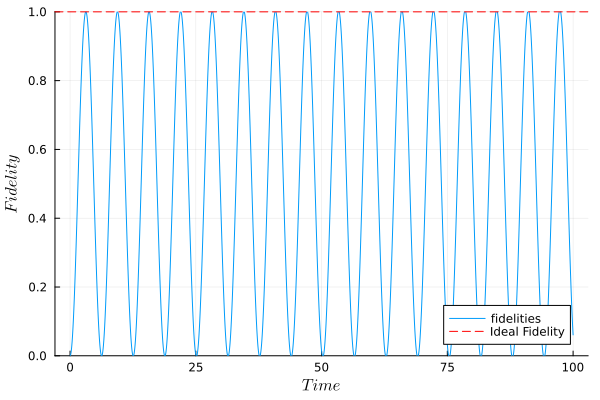

In [6]:
plot(time,real(fidelities),label="fidelities",xaxis=L"Time",yaxis=L"Fidelity",ylim=(0,1))
hline!([1], color=:red, linestyle=:dash, label="Ideal Fidelity")

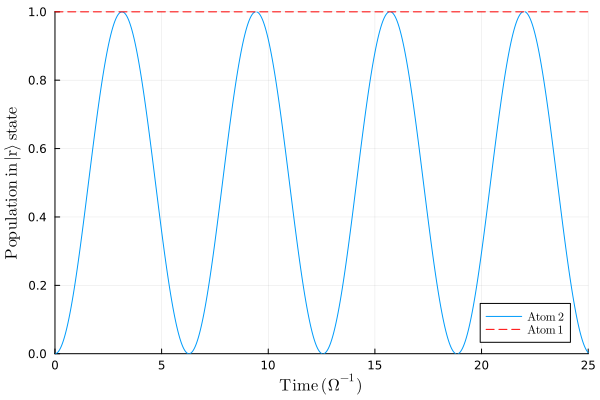

In [27]:
# Extracting populations from the solution
n = [0 0; 0 1]
I = [1 0; 0 1]

rydberg_populations = []

for ρ in sol.u
    a = tr(kron(I,n)*ρ)
    push!(rydberg_populations, a)
end

# Plotting the Rydberg state population over time
fig = plot(sol.t, rydberg_populations, fontsize=10, fontstyle="Computer Modern", xlim=[0,25], legend=:bottomright, ylim=[0,1],
label=L"\mathrm{Atom\; 2}", xlabel=L"\mathrm{Time\;(\Omega^{-1})}", ylabel=L"\mathrm{Population\;in\;|r\rangle\;state}")#, title="Population Dynamics")
hline!([1],color=:red,linestyle=:dash,label=L"\mathrm{Atom\; 1}")
savefig(fig, "/Users/akashmalemath/Documents/master_work/rydberg_thesis/rydberg_qec/images/part3/rap/1atom_rabi_plot.pdf")
display(fig)


In [41]:
ss_soln.u

4×4 Matrix{ComplexF64}:
 0.0+0.0im  0.0+0.0im       0.0+0.0im             0.0+0.0im
 0.0+0.0im  0.0+0.0im       0.0+0.0im             0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.512195+0.0im             0.0+0.0487803im
 0.0+0.0im  0.0+0.0im       0.0-0.0487803im  0.487805+0.0im

In [46]:
ρ_0 = complex(kron(r,r) * kron(r,r)')

4×4 Matrix{Complex{Int64}}:
 0+0im  0+0im  0+0im  0+0im
 0+0im  0+0im  0+0im  0+0im
 0+0im  0+0im  0+0im  0+0im
 0+0im  0+0im  0+0im  1+0im

In [42]:
tr(ss_soln.u * ss_soln.u')

0.5050564868449596 + 0.0im

In [54]:
    # ρ = ρ_0
    
    
    # σ_x = [0 1; 1 0]
    # n = [0 0; 0 1]
    # I = [1 0; 0 1]
    # σ_minus = [0 1; 0 0]
    # σ_plus = [0 0; 1 0]
    # σ_z = [1 0; 0 -1]

    # #parameters
    # Ω = 20
    # Δ = 2000
    # γ_D = 1
    # γ_d = 20

    # #ρ /= tr(ρ)
    
    # #Hamiltonian
    # H = Ω/2 .* kron(I,σ_x) + Δ .* kron(I,n) - Δ .* kron(n,n)
    # l_decay = γ_D .* (kron(I,σ_minus) * ρ * kron(I,σ_plus) - 0.5.*((kron(I,σ_plus) * kron(I,σ_minus) * ρ) + (ρ * kron(I,σ_plus) * kron(I,σ_minus))))
    # l_dephase = γ_d .* (kron(I,σ_z) * ρ * kron(I,σ_z) - 0.5.*ρ)
 
    # L = -1im .* (H*ρ - ρ*H) + l_decay + l_dephase

